In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
sns.set(style="whitegrid")

Data Loading & Inspection

In [3]:
df = pd.read_csv('../data/processed/train_cleaned.csv')


In [4]:
df.head()


,unit,cycle,os1,os2,os3,s1,s2,s3,s4,s5,...,s13,s14,s15,s16,s17,s18,s19,s20,s21,RUL
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190,191
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236,190
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442,189
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739,188
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044,187


In [5]:
df.shape

(20631, 27)

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 20631 entries, 0 to 20630
Data columns (total 27 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   unit    20631 non-null  int64  
 1   cycle   20631 non-null  int64  
 2   os1     20631 non-null  float64
 3   os2     20631 non-null  float64
 4   os3     20631 non-null  float64
 5   s1      20631 non-null  float64
 6   s2      20631 non-null  float64
 7   s3      20631 non-null  float64
 8   s4      20631 non-null  float64
 9   s5      20631 non-null  float64
 10  s6      20631 non-null  float64
 11  s7      20631 non-null  float64
 12  s8      20631 non-null  float64
 13  s9      20631 non-null  float64
 14  s10     20631 non-null  float64
 15  s11     20631 non-null  float64
 16  s12     20631 non-null  float64
 17  s13     20631 non-null  float64
 18  s14     20631 non-null  float64
 19  s15     20631 non-null  float64
 20  s16     20631 non-null  float64
 21  s17     20631 non-null  int64  
 22  s18     2

In [7]:
stats = df.describe().T
stats

,count,mean,std,min,25%,50%,75%,max
unit,20631.0,51.506568,2.922763e+01,1.0000,26.0000,52.0000,77.0000,100.0000
cycle,20631.0,108.807862,6.888099e+01,1.0000,52.0000,104.0000,156.0000,362.0000
os1,20631.0,-0.000009,2.187313e-03,-0.0087,-0.0015,0.0000,0.0015,0.0087
os2,20631.0,0.000002,2.930621e-04,-0.0006,-0.0002,0.0000,0.0003,0.0006
os3,20631.0,100.000000,0.000000e+00,100.0000,100.0000,100.0000,100.0000,100.0000
s1,20631.0,518.670000,0.000000e+00,518.6700,518.6700,518.6700,518.6700,518.6700
s2,20631.0,642.680934,5.000533e-01,641.2100,642.3250,642.6400,643.0000,644.5300
s3,20631.0,1590.523119,6.131150e+00,1571.0400,1586.2600,1590.1000,1594.3800,1616.9100
s4,20631.0,1408.933782,9.000605e+00,1382.2500,1402.3600,1408.0400,1414.5550,1441.4900
s5,20631.0,14.620000,5.329200e-15,14.6200,14.6200,14.6200,14.6200,14.6200


<Axes: >

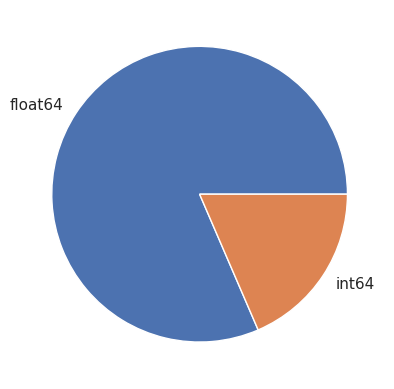

In [8]:
df.dtypes.value_counts().plot.pie()

<Axes: >

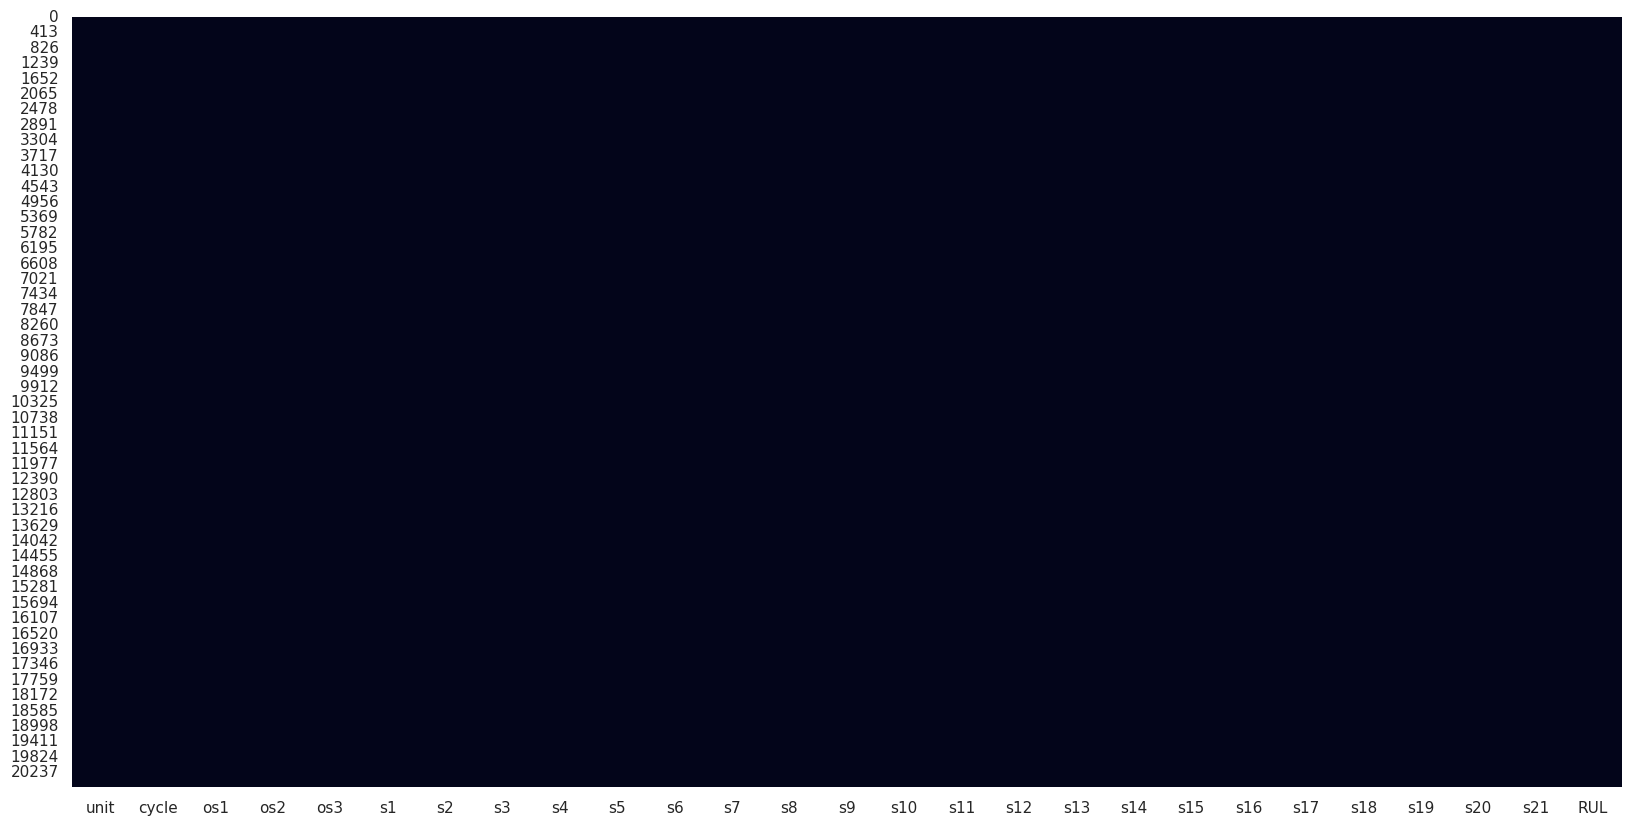

In [9]:
plt.figure(figsize=(20,10))
sns.heatmap(df.isna(), cbar=False)

In [10]:
cols = [col for col in df.columns if df[col].std() == 0]
print(f"Number of constant columns found: {len(cols)}")
print(f"List of sensors to eliminate : {cols}")


Number of constant columns found: 5
List of sensors to eliminate : ['os3', 's1', 's10', 's18', 's19']


# Target Validation & Feature Trend Analysis

To confirm the relationship between the engine's wear and the sensor data, we visualize the Remaining Useful Life (RUL) against a key feature. This step ensures that our target is correctly calculated and that the sensors actually "capture" the degradation process.

In [11]:
unit_1 = df[df['unit'] == 1]
unit_1.shape

(192, 27)

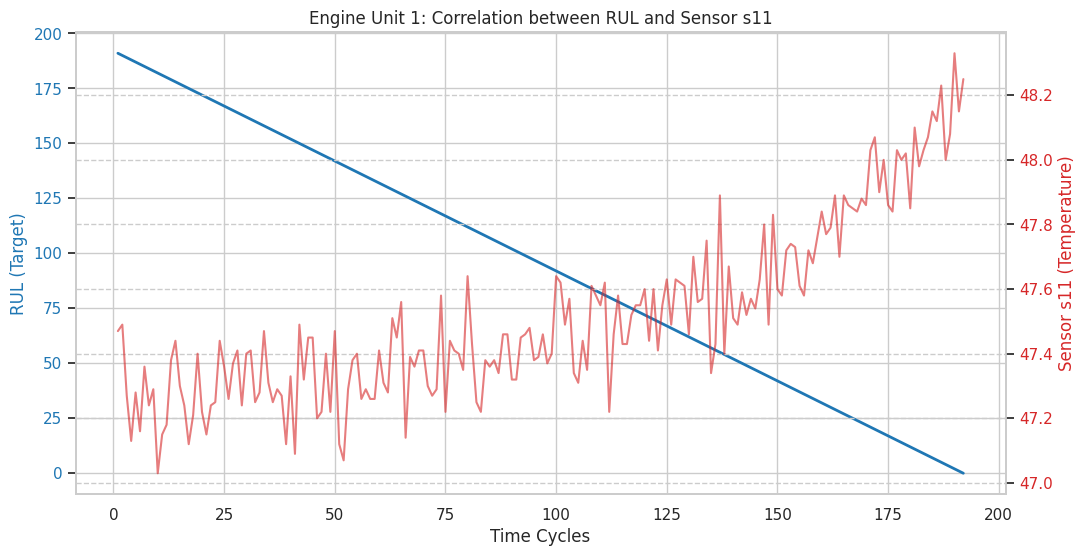

In [12]:
# 2. Create the figure and the first axis (ax1)
fig, ax1 = plt.subplots(figsize=(12, 6))

# Plot RUL (Remaining Useful Life) in blue
ax1.set_xlabel('Time Cycles')
ax1.set_ylabel('RUL (Target)', color='tab:blue')
ax1.plot(unit_1['cycle'], unit_1['RUL'], color='tab:blue', label='RUL', linewidth=2)
ax1.tick_params(axis='y', labelcolor='tab:blue')

# 3. Create a second axis (ax2) that shares the same X-axis
ax2 = ax1.twinx()
ax2.set_ylabel('Sensor s11 (Temperature)', color='tab:red')
ax2.plot(unit_1['cycle'], unit_1['s11'], color='tab:red', label='Sensor s11', alpha=0.6)
ax2.tick_params(axis='y', labelcolor='tab:red')

plt.title('Engine Unit 1: Correlation between RUL and Sensor s11')
plt.grid(True, linestyle='--')
plt.show()

Quick Insight: RUL vs. Sensor s11
Target (Blue): Ground truth RUL decreasing linearly from 192 to 0 cycles.

Signal (Red): Sensor s11 shows a clear upward trend as the engine degrades.

Key Discovery: After cycle 125, the noise and mean value increase significantly.

Conclusion: Sensor s11 is a strong predictor for the failure "signature".

# Data Cleaning

In [13]:
# 1. Drop constant sensors (zero variance) identified in Step 1
# These sensors provide no information for the model
df_cleaned = df.drop(columns=cols)

# 2. Drop non-predictive columns (like 'setting3' if it's constant too)
# Check if they are in your constant_cols list first
print(f"Original shape: {df.shape}")
print(f"Cleaned shape: {df_cleaned.shape}")
print(f"Removed columns: {cols}")

Original shape: (20631, 27)
Cleaned shape: (20631, 22)
Removed columns: ['os3', 's1', 's10', 's18', 's19']


# Data Preprocessing & Dimensionality Reduction

In [14]:
from sklearn.preprocessing import MinMaxScaler

# 1. On crée le scaler
scaler = MinMaxScaler()

# 2. On choisit les colonnes à normaliser (tous les capteurs restants)
# On exclut 'id', 'cycle', et 'RUL' car ce ne sont pas des capteurs
cols_to_scale = df_cleaned.columns.difference(['id', 'cycle', 'RUL'])

# 3. On applique la transformation
df_cleaned[cols_to_scale] = scaler.fit_transform(df_cleaned[cols_to_scale])

# Vérification : le max doit être 1 et le min 0
print(df_cleaned[cols_to_scale].describe().T[['min', 'max']])

      min  max
os1   0.0  1.0
os2   0.0  1.0
s11   0.0  1.0
s12   0.0  1.0
s13   0.0  1.0
s14   0.0  1.0
s15   0.0  1.0
s16   0.0  0.0
s17   0.0  1.0
s2    0.0  1.0
s20   0.0  1.0
s21   0.0  1.0
s3    0.0  1.0
s4    0.0  1.0
s5    0.0  0.0
s6    0.0  1.0
s7    0.0  1.0
s8    0.0  1.0
s9    0.0  1.0
unit  0.0  1.0


# Statistical Correlation & Feature Selection

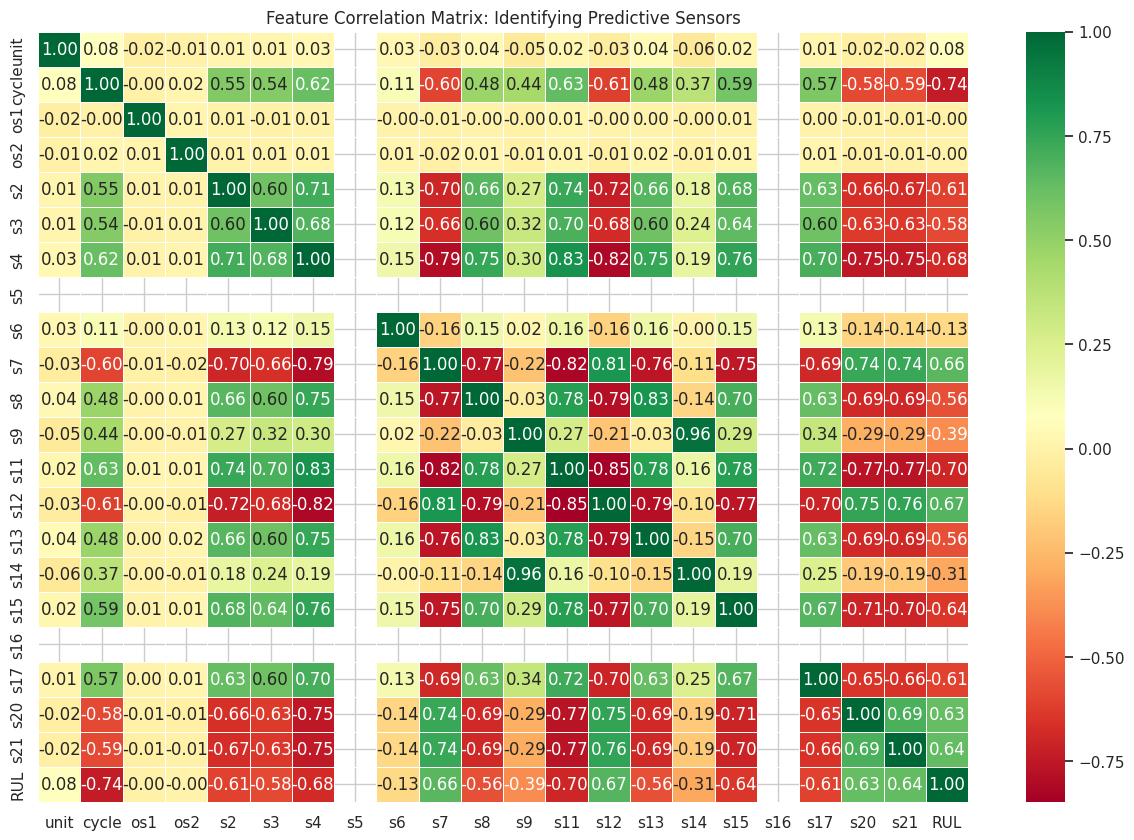

In [15]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Calcul de la matrice de corrélation sur le dataset nettoyé
corr_matrix = df_cleaned.corr()

# 2. Affichage de la Heatmap
plt.figure(figsize=(15, 10))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='RdYlGn', linewidths=0.5)

plt.title('Feature Correlation Matrix: Identifying Predictive Sensors')
plt.show()

Key Insights: Heatmap Analysis
Top Predictors: Sensors s11, s12, s4, and s7 show the strongest correlation (>0.60) with engine failure (RUL). These are our primary features.

Cleaning Validation: White zones (e.g., s5, s16) confirm that constant sensors have zero predictive power and were correctly removed.

Redundancy: High correlation between s11 and s12 indicates redundant data that the model must handle.

Conclusion: The dataset is now optimized and ready for Machine Learning.

In [16]:
df_cleaned.to_csv('../data/processed/train_cleaned.csv', index=False)